# Importing libraries and Data preprocessing

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

## Model evaluators
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

In [84]:
df=pd.read_csv(r"C:\Users\navad\Desktop\ML\Intern assignment\credit_card_fraud_dataset_modified - credit_card_fraud_dataset_modified.csv")
df.head()

,TransactionID,Amount,Time,Location,MerchantCategory,CardHolderAge,IsFraud
0,1,375.17,47605,Houston,Travel,18.0,0
1,2,950.76,38088,Los Angeles,Electronics,28.0,0
2,3,732.26,78752,Miami,Travel,20.0,0
3,4,599.06,55284,New York,Groceries,69.0,0
4,5,156.86,57043,New York,Groceries,79.0,0


In [85]:
df.shape

(500, 7)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TransactionID     500 non-null    int64  
 1   Amount            475 non-null    float64
 2   Time              500 non-null    int64  
 3   Location          475 non-null    object 
 4   MerchantCategory  500 non-null    object 
 5   CardHolderAge     476 non-null    float64
 6   IsFraud           500 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 27.5+ KB


In [87]:
df.IsFraud.value_counts()

IsFraud
0    473
1     27
Name: count, dtype: int64

In [88]:
df.IsFraud.value_counts(normalize = True)

IsFraud
0    0.946
1    0.054
Name: proportion, dtype: float64

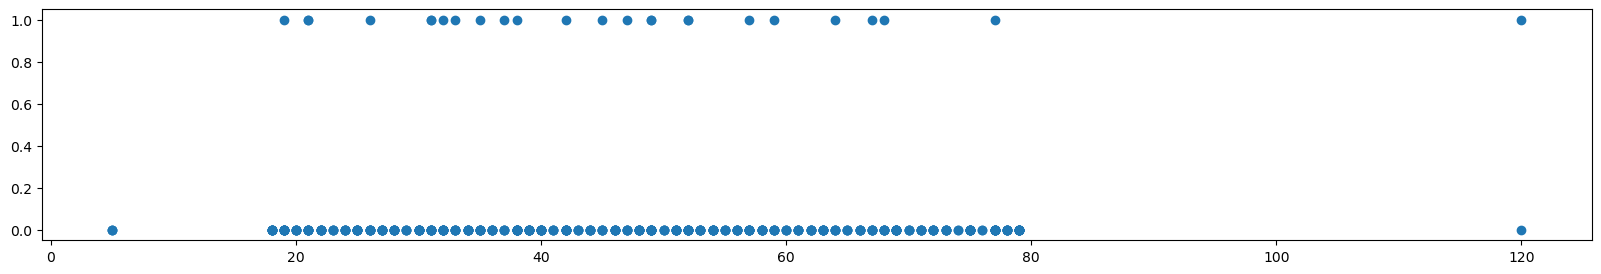

In [89]:
plt.figure(figsize=(20,3))
plt.scatter(df.CardHolderAge,df.IsFraud) 

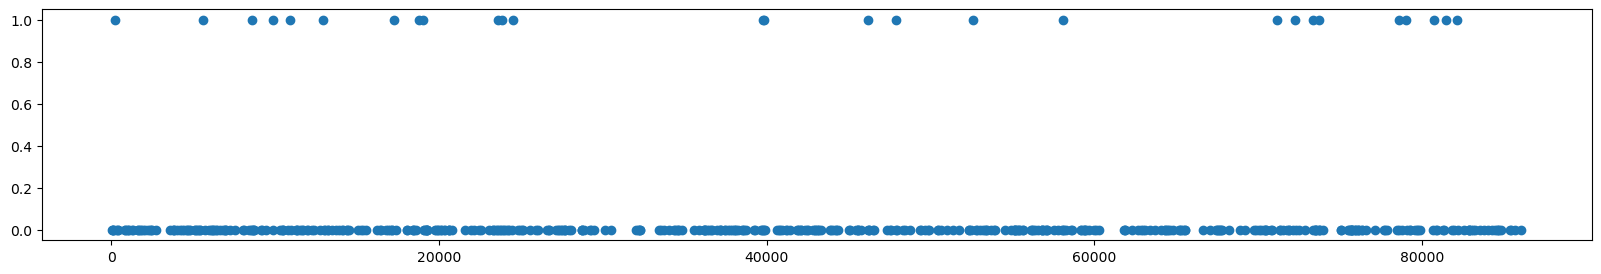

In [90]:
plt.figure(figsize=(20,3))
plt.scatter(df.Time,df.IsFraud) 

<Axes: xlabel='MerchantCategory'>

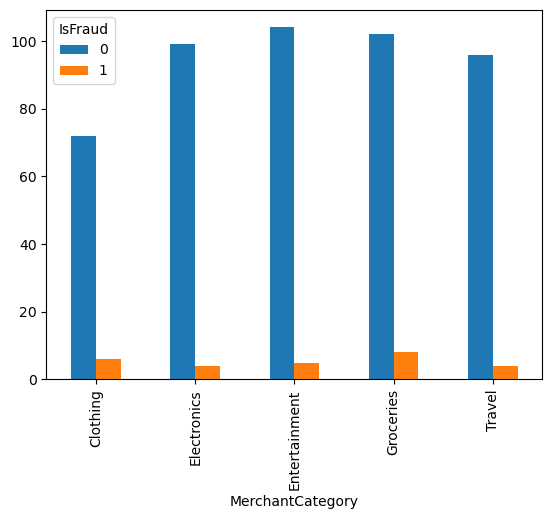

In [91]:
pd.crosstab(index=df.MerchantCategory, columns=df.IsFraud).plot(kind="bar")

<Axes: xlabel='Location'>

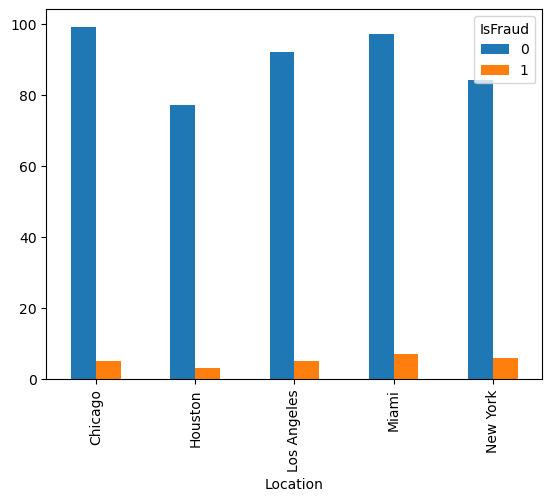

In [92]:
pd.crosstab(index=df.Location, columns=df.IsFraud).plot(kind="bar")

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TransactionID     500 non-null    int64  
 1   Amount            475 non-null    float64
 2   Time              500 non-null    int64  
 3   Location          475 non-null    object 
 4   MerchantCategory  500 non-null    object 
 5   CardHolderAge     476 non-null    float64
 6   IsFraud           500 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 27.5+ KB


## convert object datatype to integer and fill missing values

In [94]:
for label,content in df.items():
    if not pd.api.types.is_numeric_dtype(content):
        df[label] = content.astype("category").cat.codes
        
        if pd.isnull(content).sum():
            #df[label+"_is_missing"] = pd.isnull(content).astype(int)
            df[label] = pd.Categorical(content).codes + 1

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TransactionID     500 non-null    int64  
 1   Amount            475 non-null    float64
 2   Time              500 non-null    int64  
 3   Location          500 non-null    int8   
 4   MerchantCategory  500 non-null    int8   
 5   CardHolderAge     476 non-null    float64
 6   IsFraud           500 non-null    int64  
dtypes: float64(2), int64(3), int8(2)
memory usage: 20.6 KB


In [96]:
for label,content in df.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            df[label+"_is_missing"] = pd.isnull(content).astype(int)
            df[label] = content.fillna(content.median())

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TransactionID             500 non-null    int64  
 1   Amount                    500 non-null    float64
 2   Time                      500 non-null    int64  
 3   Location                  500 non-null    int8   
 4   MerchantCategory          500 non-null    int8   
 5   CardHolderAge             500 non-null    float64
 6   IsFraud                   500 non-null    int64  
 7   Amount_is_missing         500 non-null    int32  
 8   CardHolderAge_is_missing  500 non-null    int32  
dtypes: float64(2), int32(2), int64(3), int8(2)
memory usage: 24.5 KB


In [98]:
df.head() 

,TransactionID,Amount,Time,Location,MerchantCategory,CardHolderAge,IsFraud,Amount_is_missing,CardHolderAge_is_missing
0,1,375.17,47605,2,4,18.0,0,0,0
1,2,950.76,38088,3,1,28.0,0,0,0
2,3,732.26,78752,4,4,20.0,0,0,0
3,4,599.06,55284,5,3,69.0,0,0,0
4,5,156.86,57043,5,3,79.0,0,0,0


## Split the data into training and validation data and fit models

In [99]:
X = df.drop("IsFraud",axis = 1)
Y = df["IsFraud"]
X.shape, Y.shape

((500, 8), (500,))

In [100]:
X_train,X_valid,Y_train,Y_valid = train_test_split(X,Y,test_size = 0.2)
X_train.shape,Y_train.shape,X_valid.shape,Y_valid.shape

((400, 8), (400,), (100, 8), (100,))

In [102]:
%%time
model = LogisticRegression(n_jobs=-1,random_state=42)
model.fit(X_train_scaled,Y_train)

CPU times: total: 15.6 ms
Wall time: 13.6 ms


LogisticRegression(n_jobs=-1, random_state=42)

In [110]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score 
def scores(model_):
    # Predictions
    train_preds = model_.predict(X_train_scaled)
    val_preds = model_.predict(X_valid_scaled)

    sc = {
        "train_accuracy" : accuracy_score(Y_train, train_preds),
        "val_accuracy"   : accuracy_score(Y_valid, val_preds),
        
        "train_precision": precision_score(Y_train, train_preds),
        "val_precision"  : precision_score(Y_valid, val_preds),
        
        "train_recall"   : recall_score(Y_train, train_preds),
        "val_recall"     : recall_score(Y_valid, val_preds),
        
        "train_f1"       : f1_score(Y_train, train_preds),
        "val_f1"         : f1_score(Y_valid, val_preds),
    }
 
    return sc


In [114]:
scores(model)

C:\Users\navad\Desktop\env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\navad\Desktop\env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'train_accuracy': 0.94,
 'val_accuracy': 0.97,
 'train_precision': 0.0,
 'val_precision': 0.0,
 'train_recall': 0.0,
 'val_recall': 0.0,
 'train_f1': 0.0,
 'val_f1': 0.0}

In [50]:
predictions = model.predict(X_valid)

output = pd.DataFrame({' actual data': Y_valid, ' predictions': predictions})
output

,actual data,predictions
434,0,0
182,0,0
431,0,0
192,0,0
70,0,0
...,...,...
141,0,0
335,0,0
100,0,0
45,0,0


In [59]:
column_sums = output.sum(axis=0)

print(column_sums)

actual data    6
predictions    0
dtype: int64


In [52]:
%%time
model2 = RandomForestClassifier(n_jobs=-1,random_state=42)
model2.fit(X_train_scaled,Y_train)

CPU times: total: 328 ms
Wall time: 298 ms


RandomForestClassifier(n_jobs=-1, random_state=42)

In [53]:
scores(model2)

C:\Users\navad\Desktop\env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'train_accuracy': 1.0,
 'val_accuracy': 0.94,
 'train_precision': 1.0,
 'val_precision': 0.0,
 'train_recall': 1.0,
 'val_recall': 0.0,
 'train_f1': 1.0,
 'val_f1': 0.0}

In [57]:
predictions2 = model2.predict(X_valid)

output2 = pd.DataFrame({' actual data': Y_valid, ' predictions': predictions2})
output2

,actual data,predictions
434,0,0
182,0,0
431,0,0
192,0,0
70,0,0
...,...,...
141,0,0
335,0,0
100,0,0
45,0,0


In [60]:
column_sums2 = output2.sum(axis=0)

print(column_sums2)

actual data    6
predictions    0
dtype: int64


### After analyzing the data, and observing the model performances here is what I can say:
### LogisticRegression is getting pretty good accuracy but the other metrics are not satisfactory, the reason could be the baised target variable(94% no fraud case) and very low data.
### RandomForestClassifier is performing good on training data but not on valid data indicating overfitting, which could be solved by using more amounts of data to train and test.

## Let's hyper-tune the model and check the results

In [101]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)


In [74]:
%%time
model4 = LogisticRegression(n_jobs=-1,random_state=42)
model4.fit(X_train_scaled,Y_train)

CPU times: total: 46.9 ms
Wall time: 1.22 s


LogisticRegression(n_jobs=-1, random_state=42)

In [75]:
scores(model4)

C:\Users\navad\Desktop\env\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\navad\Desktop\env\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


{'train_accuracy': 0.105,
 'val_accuracy': 0.12,
 'train_precision': 0.055408970976253295,
 'val_precision': 0.06382978723404255,
 'train_recall': 1.0,
 'val_recall': 1.0,
 'train_f1': 0.105,
 'val_f1': 0.12}

In [62]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid,
                    scoring='precision', cv=5, n_jobs=-1)

grid.fit(X_train_scaled, Y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)


Best params: {'C': 100, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'saga'}
Best score: 0.054338469837695844


C:\Users\navad\Desktop\env\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [64]:
%%time
model3 = LogisticRegression(C=100,
                            class_weight='balanced',
                            penalty='l2',
                            solver='saga')
model3.fit(X_train_scaled,Y_train)

CPU times: total: 31.2 ms
Wall time: 7 ms


C:\Users\navad\Desktop\env\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(C=100, class_weight='balanced', solver='saga')

In [65]:
scores(model3)

C:\Users\navad\Desktop\env\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\navad\Desktop\env\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


{'train_accuracy': 0.2525,
 'val_accuracy': 0.27,
 'train_precision': 0.05732484076433121,
 'val_precision': 0.05333333333333334,
 'train_recall': 0.8571428571428571,
 'val_recall': 0.6666666666666666,
 'train_f1': 0.10746268656716418,
 'val_f1': 0.09876543209876543}

### After hyper-tuning we got pretty good performance. Now over-fitting doesn't happen and precision has increased. To still increase performance, training with more data helps